# Make a decision tree from scratch that classify Iris Species

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo 

# Preprocess Data and Test-Train Split

In [2]:
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
y.columns = ['Species']
df = pd.concat([X, y], axis=1)
# metadata 
print(iris.metadata) 
  
# variable information 
print(iris.variables) 

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [3]:
# first few entries of the dataset

display(df.head())

,sepal length,sepal width,petal length,petal width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# find how many examples we have for each species

df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [5]:
# convert the entries of the Species column into numbers so that they are easy to use
# make setota - 0, versicolor - 1, virginica - 2

df['Species'] = df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

In [6]:
# split the data into training and testing data

train, test = train_test_split(df, test_size=0.2, stratify=df['Species'])

# Exploratory Data Analysis 

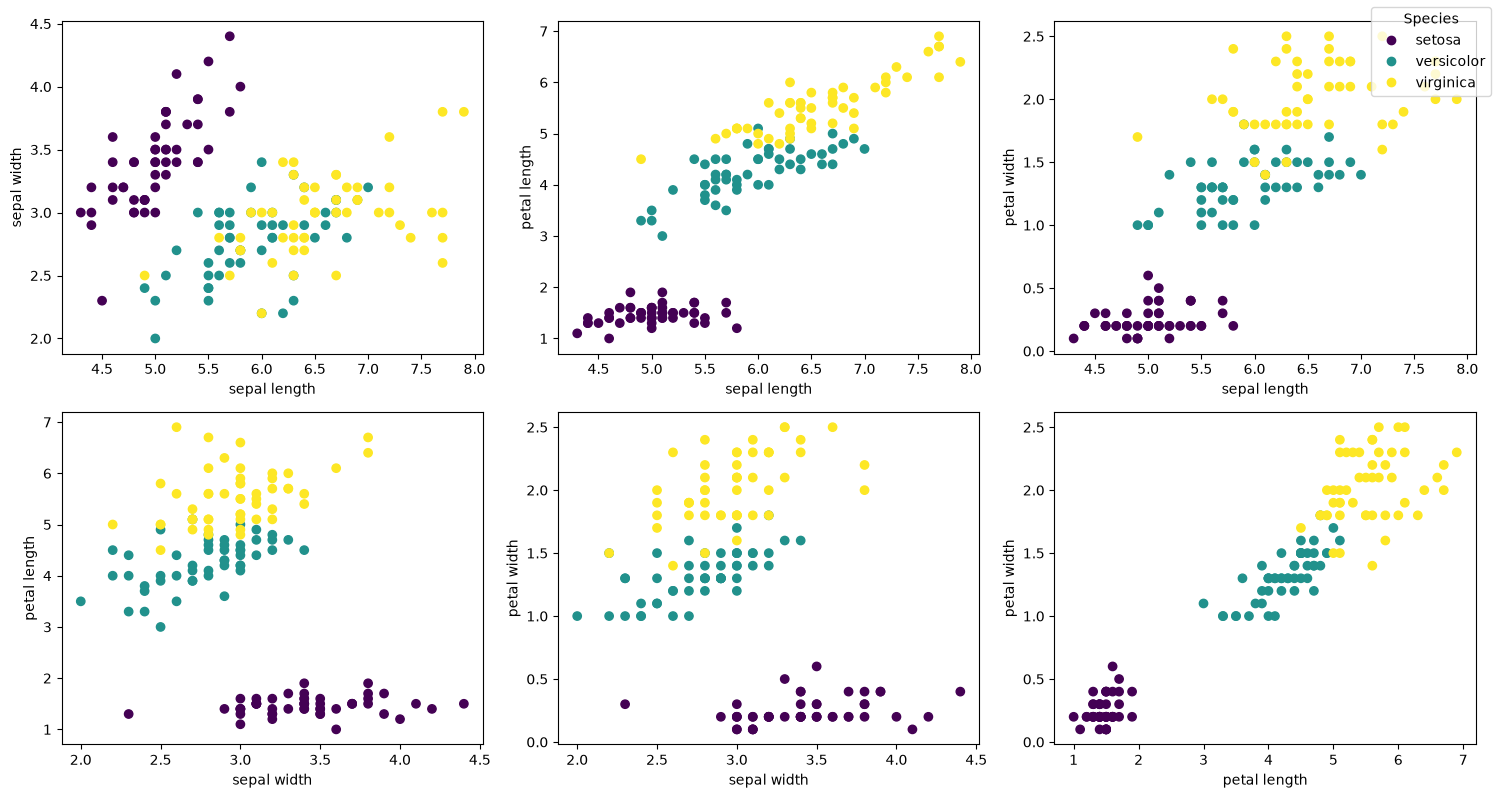

In [7]:
# plot all possible combinations of attributes and how they divide the species

from itertools import combinations

cols = ['sepal length', 'sepal width', 'petal length', 'petal width']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (x, y) in zip(axes.flat, combinations(cols, 2)):
    scatter = ax.scatter(df[x], df[y], c=df['Species'])
    ax.set_xlabel(x)
    ax.set_ylabel(y)

handles, _ = scatter.legend_elements()
fig.legend(handles, ['setosa', 'versicolor', 'virginica'], title='Species', loc='upper right')

plt.tight_layout()

# Setup and train the Decision Tree

In [8]:
def entropy(S, target_values = [0, 1, 2], target_column_name = 'Species'):
    # function that finds entropy
    S = S[target_column_name]
    ent = 0
    nS = len(S)
    for i in range(len(target_values)):
        nS_i = len([x for x in S if x == target_values[i]])
        if nS_i == 0:
            continue
        ent -= (nS_i/nS) * np.log2(nS_i/ nS)

    return ent

def information_gain(S, attribute_to_split_by, split):
    # calculate information gain at each point
    ent_S = entropy(S)
    nS = len(S)
    below = S[S[attribute_to_split_by] <= split]
    above = S[S[attribute_to_split_by] > split]
    gain = ent_S - len(below)/nS*entropy(below) - len(above)/nS*entropy(above)
    return gain

def find_best_split(S, attribute_to_split_by, target_values = [0, 1, 2], target_column_name = 'Species'):
    # arrange all the 50 values in order and find mid points for candidate splits
    values = S[attribute_to_split_by].sort_values()
    split_candidates = (values + values.shift(-1)) / 2
    split_candidates = split_candidates.dropna()
    split_candidates = split_candidates.tolist()

    best_split = 0
    best_gain = 0
    for split in split_candidates:
        gain = information_gain(S, attribute_to_split_by, split)
        if gain > best_gain:
            best_gain = gain
            best_split = split
    return best_split, best_gain

def print_tree(node, depth=1):
    # a function that prints the logic of the tree
    indent = "  " * depth
    if node.value is not None:
        print(f"{indent}-> class {node.value}")
        return
    print(f"{indent}{node.attribute} <= {node.split}?")
    print(f"{indent}True:")
    print_tree(node.left, depth + 1)
    print(f"{indent}False:")
    print_tree(node.right, depth + 1)

In [9]:
class Node:
    # An object that stores the information required of the node
    def __init__(self, attribute=None, split=None, right=None, left=None, value=None):
        self.attribute = attribute
        self.split = split
        self.right = right
        self.left = left
        self.value = value

    def display(self, depth = 1):
        print_tree(self, depth=depth)

    def infer(self, values):
        if self.value is not None:
            return self.value
        else:
            if values[self.attribute] > self.split:
                return self.right.infer(values)
            else:
                return self.left.infer(values)

def decision_tree(df, attributes):
    # loop through attributes to find information gain for the best split of each

    # best case: only one class is present
    if entropy(df) == 0:
        return Node(value=df['Species'].iloc[0])

    # base case: nothing left to split on
    if not attributes:
        return Node(value=df['Species'].mode()[0])

    # find best attribute and split
    best_split = 0
    attribute_to_split_by = None
    best_gain = 0
    for attribute in attributes:
        split, gain = find_best_split(df, attribute)
        if best_gain < gain:
            attribute_to_split_by = attribute
            best_split = split
            best_gain = gain

    # base case: no split improves entropy
    if attribute_to_split_by is None:
        return Node(value=df['Species'].mode()[0])

    below = df[df[attribute_to_split_by] <= best_split]
    above = df[df[attribute_to_split_by] > best_split]
    remaining_attributes = [a for a in attributes if a != attribute_to_split_by]
    right = decision_tree(above, attributes)
    left = decision_tree(below, attributes)

    return Node(attribute=attribute_to_split_by, split=best_split, right=right, left=left)

In [10]:
tree = decision_tree(train, ['sepal length', 'sepal width', 'petal length', 'petal width'])

In [11]:
# find accuracy
accuracy = 0
for i in range(len(test)):
    if test['Species'].iloc[i] == tree.infer(test.iloc[i]):
        accuracy += 1
accuracy = accuracy/len(test)
print(accuracy)

0.9


In [12]:
# find accuracy per class
predictions = test.apply(lambda row: tree.infer(row), axis=1)
correct = test['Species'] == predictions

accuracy_per_species = correct.groupby(test['Species']).mean()
print(accuracy_per_species)

Species
0    1.0
1    0.9
2    0.8
dtype: float64


Text(0, 0.5, 'petal width')

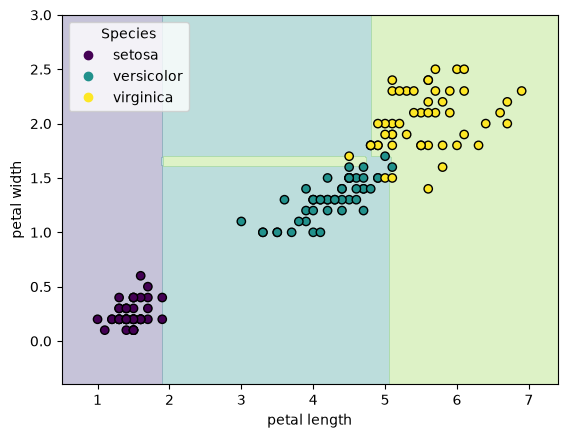

In [13]:
# visualize decision boundary (trained on 2 features only, since a boundary plot needs exactly 2 axes)
x_col, y_col = 'petal length', 'petal width'
tree_2d = decision_tree(train, [x_col, y_col])

x_min, x_max = df[x_col].min() - 0.5, df[x_col].max() + 0.5
y_min, y_max = df[y_col].min() - 0.5, df[y_col].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid = pd.DataFrame({x_col: xx.ravel(), y_col: yy.ravel()})
zz = grid.apply(lambda row: tree_2d.infer(row), axis=1).values.reshape(xx.shape)

plt.contourf(xx, yy, zz, alpha=0.3, levels=[-0.5, 0.5, 1.5, 2.5])
scatter = plt.scatter(df[x_col], df[y_col], c=df['Species'], edgecolor='k')
handles, _ = scatter.legend_elements()
plt.legend(handles, ['setosa', 'versicolor', 'virginica'], title='Species')
plt.xlabel(x_col)
plt.ylabel(y_col)